Using device: cpu
Первые 5 строк:
                 date  target
0 2025-01-01 00:00:00   98.14
1 2025-01-01 01:00:00   98.07
2 2025-01-01 02:00:00  104.70
3 2025-01-01 03:00:00  112.81
4 2025-01-01 04:00:00  112.62

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    4320 non-null   datetime64[ns]
 1   target  4320 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 67.6 KB
None

Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Количество пропусков:
date      0
target    0
dtype: int64


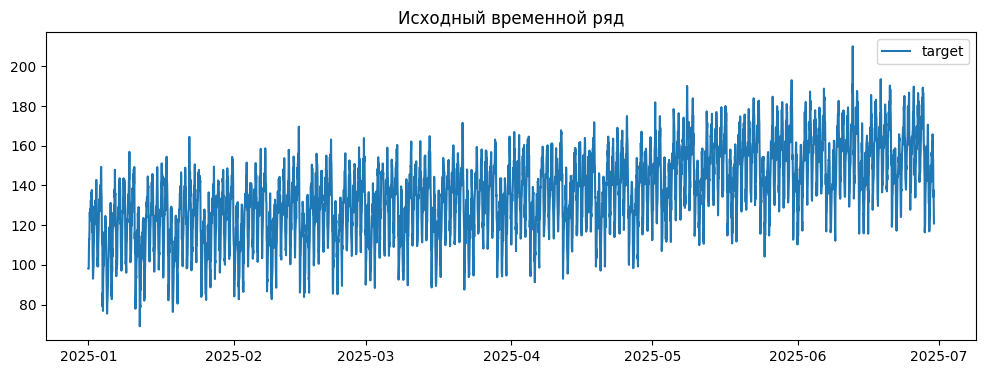

Train: 2025-01-01 00:00:00 — 2025-05-06 23:00:00  (3024 записей)
Val:   2025-05-07 00:00:00 — 2025-05-24 23:00:00  (432 записей)
Test:  2025-05-25 00:00:00 — 2025-06-29 23:00:00  (864 записей)


FileNotFoundError: [Errno 2] No such file or directory: './artifacts/figures/series_split.png'

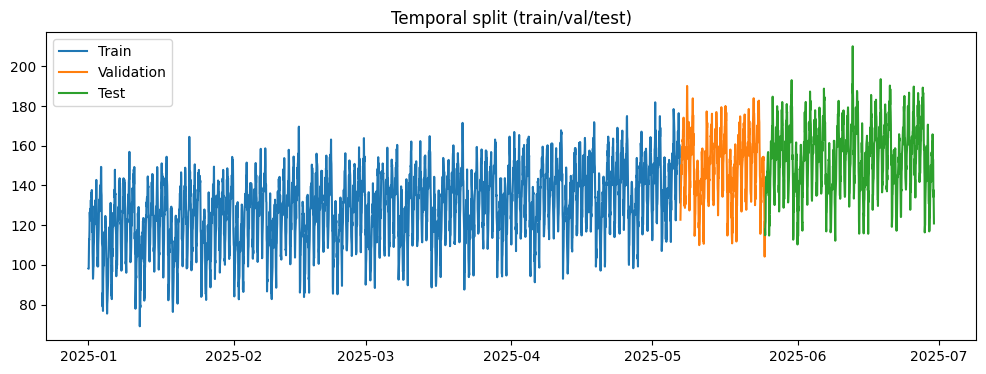

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import random
import json
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

df = pd.read_csv('S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df.sort_values('date', inplace=True)
df.reset_index(drop=True, inplace=True)

print("Первые 5 строк:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print(f"\nДиапазон дат: {df['date'].min()} — {df['date'].max()}")
print(f"Количество пропусков:\n{df.isnull().sum()}")

plt.figure(figsize=(12, 4))
plt.plot(df['date'], df['target'], label='target')
plt.title('Исходный временной ряд')
plt.legend()
plt.show()

n = len(df)
train_end = int(0.7 * n)
val_end = int(0.8 * n)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"Train: {train_df['date'].min()} — {train_df['date'].max()}  ({len(train_df)} записей)")
print(f"Val:   {val_df['date'].min()} — {val_df['date'].max()}  ({len(val_df)} записей)")
print(f"Test:  {test_df['date'].min()} — {test_df['date'].max()}  ({len(test_df)} записей)")

plt.figure(figsize=(12, 4))
plt.plot(train_df['date'], train_df['target'], label='Train')
plt.plot(val_df['date'], val_df['target'], label='Validation')
plt.plot(test_df['date'], test_df['target'], label='Test')
plt.legend()
plt.title('Temporal split (train/val/test)')
plt.savefig('./artifacts/figures/series_split.png', dpi=150)
plt.show()


def create_features(df, window=7):
    df = df.copy()
    df['lag_1'] = df['target'].shift(1)
    df['lag_7'] = df['target'].shift(7)
    df['lag_14'] = df['target'].shift(14)
    df['rolling_mean_7'] = df['target'].shift(1).rolling(window).mean()
    df['rolling_std_7'] = df['target'].shift(1).rolling(window).std()
    df['dayofweek'] = df['date'].dt.dayofweek
    df.dropna(inplace=True)
    return df

df['rolling_mean_7'] = df['target'].shift(1).rolling(7).mean()
df['rolling_std_7'] = df['target'].shift(1).rolling(7).std()
train_feat = create_features(train_df)
val_feat = create_features(val_df)
test_feat = create_features(test_df)

X_train = train_feat[['lag_1','lag_7','lag_14','rolling_mean_7','rolling_std_7','dayofweek']]
y_train = train_feat['target']
X_val = val_feat[['lag_1','lag_7','lag_14','rolling_mean_7','rolling_std_7','dayofweek']]
y_val = val_feat['target']
X_test = test_feat[['lag_1','lag_7','lag_14','rolling_mean_7','rolling_std_7','dayofweek']]
y_test = test_feat['target']

print(f"Размеры признаков: train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")

def naive_last(series):
    return series.shift(1).fillna(series.iloc[0])

def moving_average(series, window=7):
    return series.shift(1).rolling(window).mean()

preds_naive = naive_last(train_feat['target']).iloc[-len(val_feat):]
val_mae_naive = mean_absolute_error(val_feat['target'], preds_naive)
val_rmse_naive = np.sqrt(mean_squared_error(val_feat['target'], preds_naive))
val_mape_naive = mean_absolute_percentage_error(val_feat['target'], preds_naive)

preds_ma = moving_average(train_feat['target'], window=7).iloc[-len(val_feat):]
val_mae_ma = mean_absolute_error(val_feat['target'], preds_ma)
val_rmse_ma = np.sqrt(mean_squared_error(val_feat['target'], preds_ma))
val_mape_ma = mean_absolute_percentage_error(val_feat['target'], preds_ma)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
preds_ridge = ridge.predict(X_val)
val_mae_ridge = mean_absolute_error(y_val, preds_ridge)
val_rmse_ridge = np.sqrt(mean_squared_error(y_val, preds_ridge))
val_mape_ridge = mean_absolute_percentage_error(y_val, preds_ridge)

print("B1 (naive-last):")
print(f"  MAE = {val_mae_naive:.4f}, RMSE = {val_rmse_naive:.4f}, MAPE = {val_mape_naive:.4f}")
print("B2 (moving average):")
print(f"  MAE = {val_mae_ma:.4f}, RMSE = {val_rmse_ma:.4f}, MAPE = {val_mape_ma:.4f}")
print("B3 (Ridge):")
print(f"  MAE = {val_mae_ridge:.4f}, RMSE = {val_rmse_ridge:.4f}, MAPE = {val_mape_ridge:.4f}")


window_size = 14

class TimeSeriesDataset(Dataset):
    def __init__(self, series, window):
        self.series = series.values.astype(np.float32)
        self.window = window
        self.X = []
        self.y = []
        for i in range(window, len(self.series)):
            self.X.append(self.series[i-window:i])
            self.y.append(self.series[i])
        self.X = np.array(self.X)
        self.y = np.array(self.y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]).unsqueeze(-1), torch.tensor(self.y[idx])

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_series_scaled = scaler.fit_transform(train_df['target'].values.reshape(-1,1)).flatten()
val_series_scaled = scaler.transform(val_df['target'].values.reshape(-1,1)).flatten()
test_series_scaled = scaler.transform(test_df['target'].values.reshape(-1,1)).flatten()

train_dataset = TimeSeriesDataset(pd.Series(train_series_scaled), window_size)
val_dataset = TimeSeriesDataset(pd.Series(val_series_scaled), window_size)
test_dataset = TimeSeriesDataset(pd.Series(test_series_scaled), window_size)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Количество обучающих последовательностей: {len(train_dataset)}")
print(f"Количество валидационных последовательностей: {len(val_dataset)}")
print(f"Количество тестовых последовательностей: {len(test_dataset)}")

class GRUForecast(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model_gru = GRUForecast().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_gru.parameters(), lr=1e-3)

num_epochs = 50
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_state = None

for epoch in range(num_epochs):
    model_gru.train()
    total_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model_gru(X)
        loss = criterion(y_pred, y.unsqueeze(1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
    train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    model_gru.eval()
    val_loss = 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model_gru(X)
            loss = criterion(y_pred, y.unsqueeze(1))
            val_loss += loss.item() * X.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model_gru.state_dict()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}: train loss={train_loss:.4f}, val loss={val_loss:.4f}")

model_gru.load_state_dict(best_state)

def evaluate_gru(model, loader, scaler, device):
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y_pred = model(X).cpu().numpy()
            preds.extend(y_pred.flatten())
            targets.extend(y.numpy())
    preds = np.array(preds).reshape(-1,1)
    targets = np.array(targets)
    preds_orig = scaler.inverse_transform(preds).flatten()
    targets_orig = scaler.inverse_transform(targets.reshape(-1,1)).flatten()
    mae = mean_absolute_error(targets_orig, preds_orig)
    rmse = np.sqrt(mean_squared_error(targets_orig, preds_orig))
    mape = mean_absolute_percentage_error(targets_orig, preds_orig)
    return mae, rmse, mape, preds_orig, targets_orig

val_mae, val_rmse, val_mape, _, _ = evaluate_gru(model_gru, val_loader, scaler, device)
test_mae, test_rmse, test_mape, test_preds, test_targets = evaluate_gru(model_gru, test_loader, scaler, device)

print("\nGRU:")
print(f"  Validation: MAE={val_mae:.4f}, RMSE={val_rmse:.4f}, MAPE={val_mape:.4f}")
print(f"  Test:       MAE={test_mae:.4f}, RMSE={test_rmse:.4f}, MAPE={test_mape:.4f}")

all_results = [
    {'experiment_id': 'B1', 'task': 'forecasting', 'dataset': 'S12', 'seed': 42,
     'split_summary': '70/10/20 temporal', 'window_size': None, 'horizon': 1,
     'model_summary': 'naive_last', 'features_summary': 'None', 'scaler': None,
     'optimizer': None, 'lr': None, 'epochs_trained': None,
     'best_val_mae': val_mae_naive, 'best_val_rmse': val_rmse_naive, 'best_val_mape': val_mape_naive,
     'test_mae': None, 'test_rmse': None, 'test_mape': None, 'notes': ''},
    {'experiment_id': 'B2', 'task': 'forecasting', 'dataset': 'S12', 'seed': 42,
     'split_summary': '70/10/20 temporal', 'window_size': None, 'horizon': 1,
     'model_summary': 'moving_average_7', 'features_summary': 'None', 'scaler': None,
     'optimizer': None, 'lr': None, 'epochs_trained': None,
     'best_val_mae': val_mae_ma, 'best_val_rmse': val_rmse_ma, 'best_val_mape': val_mape_ma,
     'test_mae': None, 'test_rmse': None, 'test_mape': None, 'notes': ''},
    {'experiment_id': 'B3', 'task': 'forecasting', 'dataset': 'S12', 'seed': 42,
     'split_summary': '70/10/20 temporal', 'window_size': None, 'horizon': 1,
     'model_summary': 'Ridge', 'features_summary': 'lags+rolling+dayofweek', 'scaler': None,
     'optimizer': None, 'lr': None, 'epochs_trained': None,
     'best_val_mae': val_mae_ridge, 'best_val_rmse': val_rmse_ridge, 'best_val_mape': val_mape_ridge,
     'test_mae': None, 'test_rmse': None, 'test_mape': None, 'notes': ''},
    {'experiment_id': 'R1', 'task': 'forecasting', 'dataset': 'S12', 'seed': 42,
     'split_summary': '70/10/20 temporal', 'window_size': window_size, 'horizon': 1,
     'model_summary': 'GRU', 'features_summary': 'raw series', 'scaler': 'StandardScaler',
     'optimizer': 'Adam', 'lr': 1e-3, 'epochs_trained': num_epochs,
     'best_val_mae': val_mae, 'best_val_rmse': val_rmse, 'best_val_mape': val_mape,
     'test_mae': test_mae, 'test_rmse': test_rmse, 'test_mape': test_mape, 'notes': ''}
]

df_results = pd.DataFrame(all_results)
df_results.to_csv('./artifacts/runs.csv', index=False)

torch.save(best_state, './artifacts/best_gru.pt')
config = {
    'model': 'GRU',
    'input_size': 1,
    'hidden_size': 32,
    'num_layers': 1,
    'output_size': 1,
    'window_size': window_size,
    'batch_size': 32,
    'lr': 1e-3,
    'epochs': num_epochs,
    'scaler': 'StandardScaler',
    'seed': 42
}
with open('./artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=2)

plt.figure(figsize=(10,5))
plt.plot(train_losses, label='train loss')
plt.plot(val_losses, label='val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('GRU learning curves')
plt.legend()
plt.savefig('./artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()

metrics = ['best_val_mae', 'best_val_rmse', 'best_val_mape']
exp_ids = ['B1', 'B2', 'B3', 'R1']
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, met in enumerate(metrics):
    values = [df_results[df_results['experiment_id']==e][met].values[0] for e in exp_ids]
    axes[i].bar(exp_ids, values)
    axes[i].set_title(met)
plt.tight_layout()
plt.savefig('./artifacts/figures/baselines_compare.png', dpi=150)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(test_targets, label='Actual')
plt.plot(test_preds, label='GRU forecast')
plt.legend()
plt.title('Best model forecast on test set')
plt.savefig('./artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()